## 预测

In [46]:
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

checkpoint_path = str(Path.cwd().parent / "models" / "truncated-distilbert-base-multilingual-cased-sentiment" / "best-model")

model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)
tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)

model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)

In [47]:
def predict(text, model, tokenizer):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=False
    )

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)
        probabilities = torch.softmax(logits, dim=-1)

    return {
        "predictions": predictions.item(),
        "label": model.config.id2label[predictions.item()],
        "probabilities": probabilities[0].tolist()
    }

In [48]:
text = "じゃない"
result = predict(text, model, tokenizer)
print(f"Text: {text}")
print(f"Predicted label: {result['label']}")
print(f"Prediction ID: {result['predictions']}")
print(f"Probabilities: {result['probabilities']}")

Text: じゃない
Predicted label: negative
Prediction ID: 2
Probabilities: [0.014301750808954239, 0.03406044468283653, 0.9516378045082092]


## 绘制混淆矩阵

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset


def plot_confusion_matrix(y_preds, y_true, labels):
    """绘制归一化混淆矩阵"""
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized Confusion Matrix")
    plt.show()

In [50]:
dataset = load_dataset("clapAI/MultiLingualSentiment")
id2label = model.config.id2label
label2id = model.config.label2id

In [51]:
def preprocess_function(examples):
    tokenized = tokenizer(examples["text"], truncation=True, max_length=192, padding=True)
    tokenized["label"] = [label2id[l] for l in examples["label"]]
    return tokenized


test_ds = dataset["test"].shuffle(seed=42).select(range(512))
test_ds = test_ds.map(preprocess_function, batched=True).remove_columns(
    ["token_type_ids", "source", "domain", "text", "language"])
print(test_ds[:2])

Map:   0%|          | 0/512 [00:00<?, ? examples/s]

{'label': [2, 2], 'input_ids': [[101, 8932, 37712, 9414, 14843, 107657, 10459, 9368, 55358, 58931, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2080, 4279, 4097, 6860, 5399, 2597, 6546, 1882, 2395, 6195, 2135, 2361, 2247, 10064, 37659, 11211, 6670, 5718, 3493, 3634, 10064, 5765, 2078, 2724, 3199, 8267, 5765, 2146, 119, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [52]:
input_ids = torch.tensor(test_ds["input_ids"]).to(model.device)  # shape: (512, max_length)
attention_mask = torch.tensor(test_ds["attention_mask"]).to(model.device)  # shape: (512, max_length)
labels = test_ds["label"]

model.eval()
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits  # shape: (512, num_classes)
    predictions = torch.argmax(logits, dim=-1)  # shape: (512,)

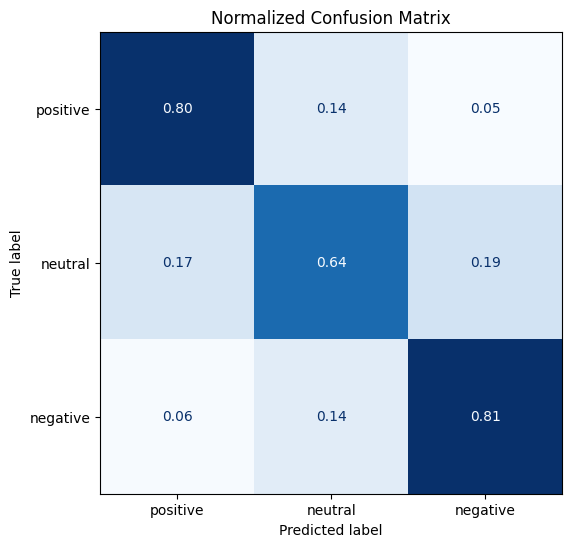

In [53]:
y_preds = predictions.cpu().numpy()
y_true = np.array(labels)

labels = [id2label[i] for i in sorted(id2label.keys())]

plot_confusion_matrix(y_preds, y_true, labels)